# Predicción de admisión universitaria con regresión logística

Este cuaderno reproduce en Python el flujo construido en **Orange Data Mining**:

1. Cargar el dataset.
2. Explorar las variables.
3. Separar los datos en **70 % entrenamiento** y **30 % prueba**.
4. Preprocesar variables numéricas y categóricas.
5. Entrenar una **regresión logística**.
6. Generar predicciones para el conjunto de prueba.
7. Calcular **accuracy, AUC, F1, precision y recall**.
8. Visualizar la **matriz de confusión** y la **curva ROC**.
9. Examinar los casos individuales y los coeficientes del modelo.

> **Nota:** los datos de GradCafe son autodeclarados. Este análisis es didáctico y exploratorio, no un sistema real de selección universitaria.

## 1. Importar bibliotecas

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)
RANDOM_STATE = 42

## 2. Cargar el dataset

In [2]:
def localizar_archivo(nombre):
    candidatos = [Path(nombre), Path("/mnt/data") / nombre]
    for ruta in candidatos:
        if ruta.exists():
            return ruta
    raise FileNotFoundError(
        f"No se encontró {nombre}. Colóquelo en la misma carpeta del cuaderno."
    )

RUTA_DATOS = localizar_archivo("admisiones_gradcafe_operaciones_orange.csv")
df = pd.read_csv(RUTA_DATOS)

# Eliminar caracteres de control que pueden aparecer en algunos nombres.
for columna in df.select_dtypes(include="object").columns:
    df[columna] = (
        df[columna]
        .astype(str)
        .str.replace(r"[\x00-\x1F\x7F]", "", regex=True)
        .str.strip()
    )

print(f"Archivo: {RUTA_DATOS}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
display(df.head())

Archivo: admisiones_gradcafe_operaciones_orange.csv
Filas: 273
Columnas: 11


,ID,Institucion,Programa,Nivel,Semestre,Anio,GPA,GRE_Verbal,GRE_Cuantitativo,GRE_Escritura,Admision
0,1,University Of Texas At Austin,Operations Research,Maestria,Otono,2019,3.78,162,170,4.5,Admitido
1,2,Columbia University (Fu Foundation),Industrial Engineering And Operations Research...,Doctorado,Otono,2019,4.00,163,170,4.0,Admitido
2,3,Cornell University,Operations Research And Information Engineering,Doctorado,Otono,2019,4.00,163,170,4.0,Admitido
3,4,Georgia Institute Of Technology,Operations Research,Doctorado,Otono,2019,3.98,154,164,4.5,Admitido
4,5,Georgia Institute Of Technology (Gatech Georgi...,Operations Research,Doctorado,Otono,2019,3.60,152,167,0.0,Rechazado


## 3. Exploración inicial

In [3]:
resumen = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "Valores_faltantes": df.isna().sum(),
    "Valores_unicos": df.nunique(),
})
display(resumen)

print("\nDistribución del target:")
display(
    df["Admision"]
    .value_counts()
    .rename_axis("Clase")
    .to_frame("Cantidad")
    .assign(Porcentaje=lambda x: (100 * x["Cantidad"] / len(df)).round(2))
)

,Tipo,Valores_faltantes,Valores_unicos
ID,int64,0,273
Institucion,object,0,99
Programa,object,0,53
Nivel,object,0,2
Semestre,object,0,2
Anio,int64,0,8
GPA,float64,0,60
GRE_Verbal,int64,0,29
GRE_Cuantitativo,int64,0,22
GRE_Escritura,float64,0,10



Distribución del target:


,Cantidad,Porcentaje
Clase,,
Admitido,165,60.44
Rechazado,108,39.56


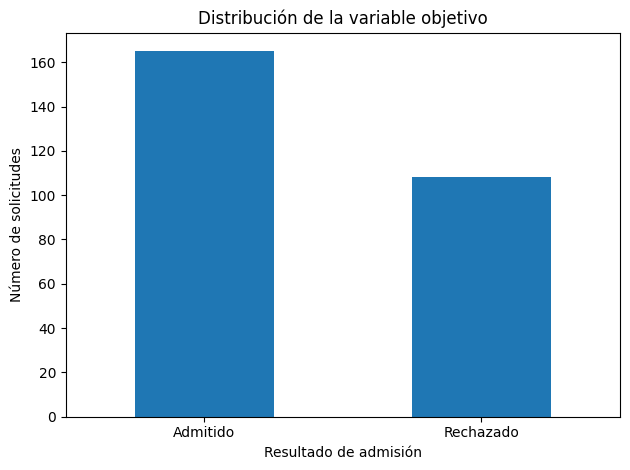

In [4]:
df["Admision"].value_counts().plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Resultado de admisión")
plt.ylabel("Número de solicitudes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Definir features y target

- **Target:** `Admision`
- **Clase positiva:** `Admitido`
- `ID` se elimina porque es solamente un identificador y no debe ayudar al modelo.

In [5]:
TARGET = "Admision"
CLASE_POSITIVA = "Admitido"

X = df.drop(columns=["ID", TARGET])
y = df[TARGET]

columnas_numericas = X.select_dtypes(include=np.number).columns.tolist()
columnas_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:")
print(columnas_numericas)
print("\nVariables categóricas:")
print(columnas_categoricas)
print(f"\nNúmero total de features originales: {X.shape[1]}")

Variables numéricas:
['Anio', 'GPA', 'GRE_Verbal', 'GRE_Cuantitativo', 'GRE_Escritura']

Variables categóricas:
['Institucion', 'Programa', 'Nivel', 'Semestre']

Número total de features originales: 9


## 5. Separar entrenamiento y prueba

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Entrenamiento: {len(X_train)} registros ({len(X_train)/len(X):.1%})")
print(f"Prueba:        {len(X_test)} registros ({len(X_test)/len(X):.1%})")

comparacion = pd.concat(
    [
        y_train.value_counts(normalize=True).rename("Entrenamiento"),
        y_test.value_counts(normalize=True).rename("Prueba"),
    ],
    axis=1,
).mul(100).round(2)

display(comparacion)

Entrenamiento: 191 registros (70.0%)
Prueba:        82 registros (30.0%)


,Entrenamiento,Prueba
Admision,,
Admitido,60.21,60.98
Rechazado,39.79,39.02


## 6. Preprocesamiento y modelo

El pipeline realiza automáticamente:

- Imputación de faltantes numéricos con la mediana.
- Estandarización de variables numéricas.
- Imputación de faltantes categóricos con la moda.
- Codificación *one-hot* de las categorías.
- Entrenamiento de una regresión logística con regularización L2.

In [7]:
preprocesador_numerico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler()),
    ]
)

preprocesador_categorico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        ("numericas", preprocesador_numerico, columnas_numericas),
        ("categoricas", preprocesador_categorico, columnas_categoricas),
    ]
)

modelo = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "regresion_logistica",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                max_iter=5000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('regresion_logistica', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

## 7. Entrenar el modelo

In [8]:
modelo.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 8. Predicciones sobre el conjunto de prueba

In [9]:
y_pred = modelo.predict(X_test)
clases_modelo = modelo.named_steps["regresion_logistica"].classes_
indice_positivo = list(clases_modelo).index(CLASE_POSITIVA)
y_prob = modelo.predict_proba(X_test)[:, indice_positivo]

predicciones = X_test.copy()
predicciones["Admision_real"] = y_test
predicciones["Admision_predicha"] = y_pred
predicciones["Probabilidad_Admitido"] = y_prob
predicciones["Prediccion_correcta"] = (
    predicciones["Admision_real"] == predicciones["Admision_predicha"]
)

predicciones = predicciones.sort_values(
    "Probabilidad_Admitido", ascending=False
)

display(predicciones.head(15))

,Institucion,Programa,Nivel,Semestre,Anio,GPA,GRE_Verbal,GRE_Cuantitativo,GRE_Escritura,Admision_real,Admision_predicha,Probabilidad_Admitido,Prediccion_correcta
134,Columbia University,Operations Research,Maestria,Otono,2015,3.98,167,162,5.0,Admitido,Admitido,0.958161,True
254,University Of California Berkeley,Industrial Engineering And Operations Research,Maestria,Otono,2013,3.99,170,169,4.0,Admitido,Admitido,0.950878,True
24,UC Berkeley,Industrial Engineering & Operations Research (...,Maestria,Otono,2018,4.00,167,158,4.0,Admitido,Admitido,0.950011,True
231,Columbia University,Operations Research,Maestria,Otono,2013,3.95,162,166,4.0,Admitido,Admitido,0.946520,True
235,Cornell University,Operations Research And Information Engineering,Maestria,Otono,2013,3.95,162,168,3.0,Admitido,Admitido,0.934161,True
31,Cornell Tech,Operations Research And Information Engineerin...,Maestria,Otono,2018,4.00,164,170,5.5,Admitido,Admitido,0.925583,True
9,Massachusetts Institute Of Technology (MIT),Operations Research,Maestria,Otono,2019,3.98,162,170,4.0,Rechazado,Admitido,0.915691,False
138,Cornell University,Operations Research And Information Engineering,Maestria,Otono,2015,3.80,164,167,4.5,Admitido,Admitido,0.915583,True
272,University Of California At Berkeley (UC Berke...,Industrial Engineering Operations Research (IEOR),Maestria,Otono,2012,3.90,170,166,4.5,Admitido,Admitido,0.911922,True
239,Georgia Institute Of Technology,Operations Research,Maestria,Otono,2013,3.91,155,167,3.5,Admitido,Admitido,0.908493,True


## 9. Accuracy y otras métricas

In [10]:
y_test_binario = (y_test == CLASE_POSITIVA).astype(int)
y_pred_binario = (y_pred == CLASE_POSITIVA).astype(int)

metricas = pd.DataFrame(
    {
        "Métrica": ["Accuracy", "AUC", "F1", "Precision", "Recall"],
        "Valor": [
            accuracy_score(y_test, y_pred),
            roc_auc_score(y_test_binario, y_prob),
            f1_score(y_test_binario, y_pred_binario),
            precision_score(y_test_binario, y_pred_binario),
            recall_score(y_test_binario, y_pred_binario),
        ],
    }
)
metricas["Valor"] = metricas["Valor"].round(4)
display(metricas)

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, digits=4))

,Métrica,Valor
0,Accuracy,0.6463
1,AUC,0.7056
2,F1,0.7238
3,Precision,0.6909
4,Recall,0.7600


Reporte de clasificación:
              precision    recall  f1-score   support

    Admitido     0.6909    0.7600    0.7238        50
   Rechazado     0.5556    0.4688    0.5085        32

    accuracy                         0.6463        82
   macro avg     0.6232    0.6144    0.6161        82
weighted avg     0.6381    0.6463    0.6398        82



## 10. Matriz de confusión

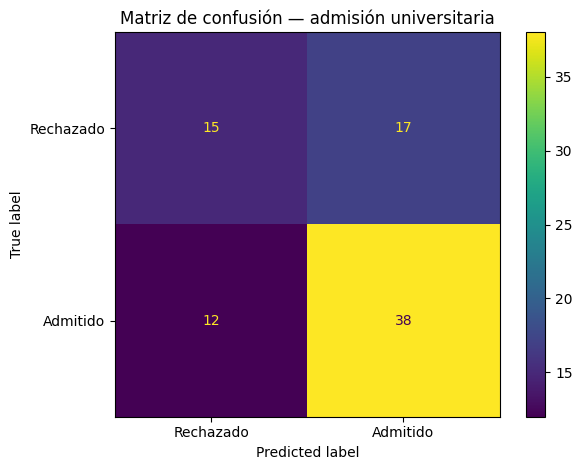

,Predicho_Rechazado,Predicho_Admitido
Real_Rechazado,15,17
Real_Admitido,12,38


In [11]:
orden_clases = ["Rechazado", "Admitido"]
matriz = confusion_matrix(y_test, y_pred, labels=orden_clases)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=orden_clases,
)
disp.plot(values_format="d")
plt.title("Matriz de confusión — admisión universitaria")
plt.tight_layout()
plt.show()

pd.DataFrame(
    matriz,
    index=[f"Real_{c}" for c in orden_clases],
    columns=[f"Predicho_{c}" for c in orden_clases],
)

## 11. Curva ROC

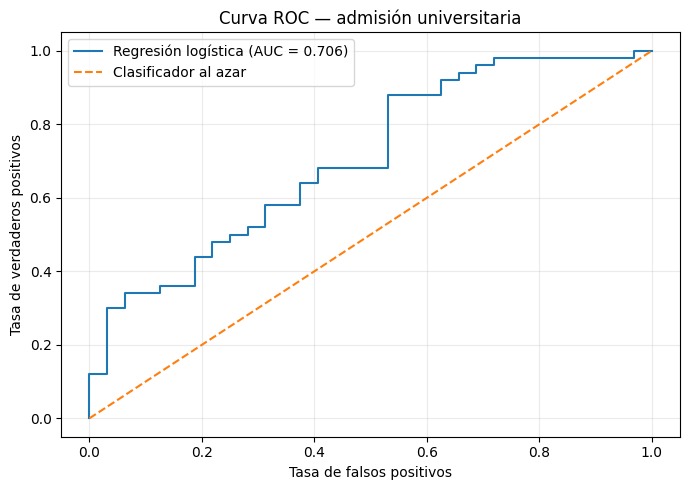

In [12]:
fpr, tpr, umbrales = roc_curve(y_test_binario, y_prob)
auc = roc_auc_score(y_test_binario, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Regresión logística (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador al azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC — admisión universitaria")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 12. Revisar aciertos y errores

In [13]:
errores = predicciones.loc[~predicciones["Prediccion_correcta"]]
aciertos = predicciones.loc[predicciones["Prediccion_correcta"]]

print(f"Aciertos: {len(aciertos)}")
print(f"Errores:  {len(errores)}")
display(errores.head(20))

Aciertos: 53
Errores:  29


,Institucion,Programa,Nivel,Semestre,Anio,GPA,GRE_Verbal,GRE_Cuantitativo,GRE_Escritura,Admision_real,Admision_predicha,Probabilidad_Admitido,Prediccion_correcta
9,Massachusetts Institute Of Technology (MIT),Operations Research,Maestria,Otono,2019,3.98,162,170,4.0,Rechazado,Admitido,0.915691,False
4,Georgia Institute Of Technology (Gatech Georgi...,Operations Research,Doctorado,Otono,2019,3.60,152,167,0.0,Rechazado,Admitido,0.883094,False
243,Massachusetts Institute Of Technology (MIT),Operations Research,Maestria,Otono,2013,3.95,162,168,3.0,Rechazado,Admitido,0.866647,False
252,UC Berkeley,Industrial Engineering And Operations Research...,Maestria,Otono,2013,3.90,152,164,3.0,Rechazado,Admitido,0.853289,False
119,UC Berkeley,Industrial Engineering And Operations Research...,Maestria,Otono,2016,3.76,151,170,3.0,Rechazado,Admitido,0.844588,False
152,MIT,Operations Research,Maestria,Otono,2015,3.78,162,167,4.0,Rechazado,Admitido,0.835462,False
246,Tepper School Of Business CMU,Operations Research,Doctorado,Otono,2013,3.80,166,166,4.5,Rechazado,Admitido,0.798921,False
81,University Of Texas At Austin,Operations Research & Industrial Engineering (...,Maestria,Otono,2016,3.40,155,165,4.0,Rechazado,Admitido,0.774582,False
260,Columbia FFSEASS,Operations Research,Doctorado,Otono,2012,3.96,170,150,4.0,Rechazado,Admitido,0.766029,False
200,Georgia Tech,Operations Research,Maestria,Otono,2014,3.20,157,164,3.5,Rechazado,Admitido,0.751188,False


## 13. Interpretar los coeficientes

En una regresión logística:

- Coeficiente positivo: aumenta la probabilidad estimada de `Admitido`.
- Coeficiente negativo: disminuye la probabilidad estimada de `Admitido`.
- La magnitud indica la fuerza de la asociación dentro del modelo.

Esto **no demuestra causalidad** y debe interpretarse con cuidado, especialmente por el tamaño y la naturaleza autodeclarada del dataset.

In [14]:
nombres_features = (
    modelo.named_steps["preprocesamiento"].get_feature_names_out()
)
coeficientes = modelo.named_steps["regresion_logistica"].coef_[indice_positivo]

tabla_coeficientes = pd.DataFrame(
    {
        "Feature_transformada": nombres_features,
        "Coeficiente": coeficientes,
    }
)
tabla_coeficientes["Magnitud"] = tabla_coeficientes["Coeficiente"].abs()

print("Variables con mayor asociación positiva con Admitido:")
display(
    tabla_coeficientes
    .sort_values("Coeficiente", ascending=False)
    .head(15)
)

print("Variables con mayor asociación negativa con Admitido:")
display(
    tabla_coeficientes
    .sort_values("Coeficiente", ascending=True)
    .head(15)
)

Variables con mayor asociación positiva con Admitido:


,Feature_transformada,Coeficiente,Magnitud
52,categoricas__Institucion_Princeton University,1.534985,1.534985
39,categoricas__Institucion_Massachusetts Institu...,1.412672,1.412672
33,categoricas__Institucion_MIT,1.328242,1.328242
69,categoricas__Institucion_University Of Califor...,0.997115,0.997115
90,categoricas__Programa_Industrial Engineering &...,0.918432,0.918432
127,categoricas__Nivel_Doctorado,0.776297,0.776297
35,categoricas__Institucion_Masachucettes Institu...,0.713187,0.713187
37,categoricas__Institucion_Massachusett Institut...,0.678359,0.678359
31,categoricas__Institucion_Georgia Tech,0.621172,0.621172
115,categoricas__Programa_Operations Research And ...,0.563297,0.563297


Variables con mayor asociación negativa con Admitido:


,Feature_transformada,Coeficiente,Magnitud
103,categoricas__Programa_Operations Research,-1.018043,1.018043
128,categoricas__Nivel_Maestria,-0.782723,0.782723
2,numericas__GRE_Verbal,-0.778527,0.778527
80,categoricas__Institucion_University Of Texas A...,-0.676246,0.676246
45,categoricas__Institucion_North Carolina State ...,-0.674691,0.674691
47,categoricas__Institucion_North Carolina State ...,-0.647564,0.647564
56,categoricas__Institucion_Rutgers Business School,-0.647564,0.647564
53,"categoricas__Institucion_Princeton, ORFE",-0.577640,0.577640
95,categoricas__Programa_Industrial Engineering/O...,-0.531007,0.531007
30,categoricas__Institucion_Georgia Institute Of ...,-0.531007,0.531007


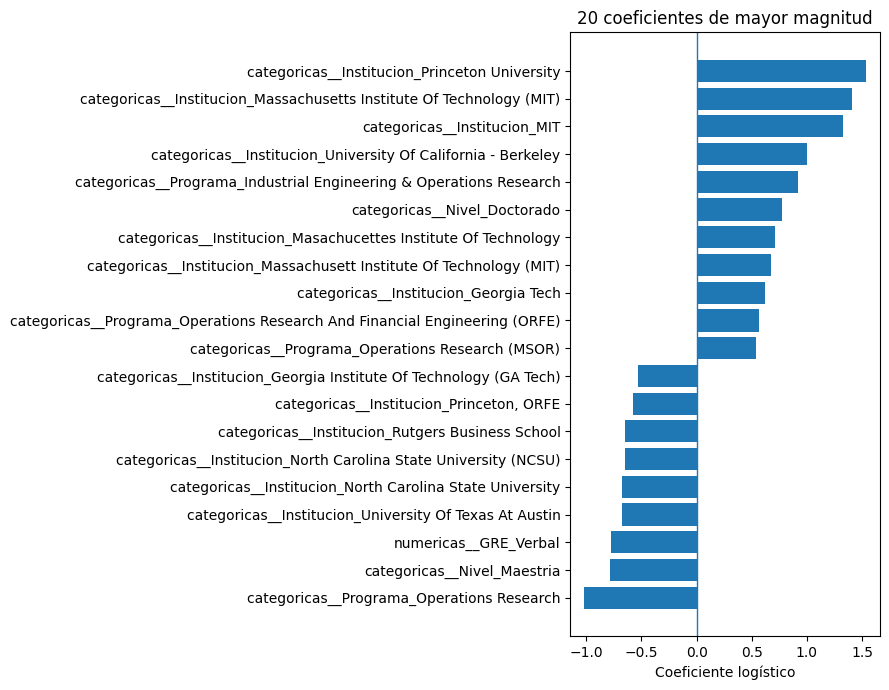

In [15]:
top_coef = (
    tabla_coeficientes
    .nlargest(20, "Magnitud")
    .sort_values("Coeficiente")
)

plt.figure(figsize=(9, 7))
plt.barh(top_coef["Feature_transformada"], top_coef["Coeficiente"])
plt.axvline(0, linewidth=1)
plt.title("20 coeficientes de mayor magnitud")
plt.xlabel("Coeficiente logístico")
plt.tight_layout()
plt.show()

## 14. Guardar las predicciones

In [16]:
SALIDA = Path("predicciones_admision_regresion_logistica.csv")
predicciones.to_csv(SALIDA, index=False, encoding="utf-8-sig")
print(f"Predicciones guardadas en: {SALIDA.resolve()}")

Predicciones guardadas en: /mnt/data/predicciones_admision_regresion_logistica.csv


## Conclusión

El cuaderno reproduce el flujo de Orange con una separación independiente de entrenamiento y prueba. La métrica más importante depende del objetivo:

- **Accuracy:** proporción global de aciertos.
- **Precision:** qué proporción de los predichos como admitidos realmente lo fue.
- **Recall:** qué proporción de los admitidos reales fue detectada.
- **F1:** equilibrio entre precision y recall.
- **AUC:** capacidad del modelo para ordenar casos positivos por encima de negativos a través de distintos umbrales.